# 🔐 PROJECT ZERO — WEEK 4
## Tech0 Search v1.0 — ランキング＆チーム開発ノートブック

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー
## Week 3 終了時フィードバック ＋ Week4指令書を確認

```
┌─────────────────────────────────────────────────────────────┐
│  💬 CDO黒崎のフィードバック                                  │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━    │
│                                                             │
│  URL入れるだけで情報が取れるのか。これはいい。進歩だ。       │
│  本文検索もできるようになったな。                            │
│                                                             │
│  ......ただ、一つ気になることがある。                       │
│                                                             │
│  「DX」で検索したら15件ヒットした。                         │
│  この並び順は、何で決まっている？                           │
│                                                             │
│  ......マッチ数順？                                         │
│                                                             │
│  それだと「DX」を100回書いたページが1位になるぞ。            │
│  そんなページが本当に役立つのか？                            │
│                                                             │
│  Googleは、なぜあんなに的確な順番で出してくるんだ？          │
│  そこを解明して、来週実装しろ。                              │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```
```
┌─────────────────────────────────────────────────────────────┐
│  📋 Week 4 指令書                           PROJECT ZERO    │
│                                                             │
│  いよいよ大詰めだ。                                          │
│  来週の役員会デモまで、あと2週間を切った。                   │
│                                                             │
│  検索結果を「賢く」並べろ。                                   │
│  マッチ数だけじゃダメだ。                                    │
│  本当に関連性の高いページが上に来るようにしろ。              │
│                                                             │
│  これは一人で抱えるな。チームを組め。                        │
│                                                             │
│                                      CDO 黒崎               │
└─────────────────────────────────────────────────────────────┘
```

## このノートブックの進め方

| ステップ | 内容 | ポイント |進め方｜
|----------|------|----------|----------|
| **Step 0** | UI設計（v1.0の完成画面） | 変化を先にイメージしよう |個人（全員）
| **Step 1** | 全体設計図とチーム役割分担 | ファイル構成とデータの流れを把握する |個人（全員）
| **Step 2** | TF-IDFとは何か（概念） | 「なぜmatch_countではダメか」から理解する |個人（全員）
| **Step 3** | コサイン類似度とは何か | ベクトル化と文書の「近さ」の測り方を理解する |個人（全員）
| **Step 4** | SearchEngineクラスの実装 | 手計算 → scikit-learn → クラス化の順で進める |チーム活動（分担OK）
| **Step 5** | DB設計及び移行 | schema.sql・database.py を一から構築する |チーム活動（分担OK）
| **Step 6** | app.py v1.0 に統合する | すべてのパーツを組み合わせて完成させる |チーム活動（分担OK）
| **Step 7** | （発展）アレンジ課題 | さらに高度な機能に挑戦しよう |発展：チーム方針または個人の興味関心

# Step 0：UI設計

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### コードを書く前に、「完成図面」をイメージする

「どんな画面を作るか」を設計します。

今回は week3 からの「進化」がテーマ。
何が変わるのか、自分の言葉でイメージしてから先に進もう。

**描いてほしいもの：**

1. 検索結果の画面（スコアの表示方法は？ 順位の見せ方は？）
2. 統計ダッシュボードの画面（どんな数字やグラフを見せたい？）
3. タブのラベルとアイコン（week3 と何が変わる？）

### 〈v1.0 の完成イメージ〉

手書きを描いたら、下の画面イメージと比べてみよう。

```
┌────────────────────────────────────────────────────────────┐
│  🔍 Tech0 Search v1.0                                       │
│  PROJECT ZERO — 社内ナレッジ検索エンジン【TF-IDFランキング搭載】│
│  ─────────────────────────────────────────────────────────  │
│  [ 🔍 検索 ] [ 🤖 クローラー ] [ 📋 一覧 ] 　　　　　　　     │
│  ─────────────────────────────────────────────────────────  │
│                                                             │
│  🔍 キーワードを入力  [  DX 製造業        ] [件数 10 ▼]     │
│                                                             │
│  📊 検索結果：3件（TF-IDFスコア順）                          │
│  ─────────────────────────────────────────────────────────  │
│  🥇  DX戦略レポート2024              スコア  42.3           │
│      デジタルトランスフォーメーションの最前線...              │
│      🏷️ `DX` `製造業` `IoT`          基準: 35.1            │
│  ─────────────────────────────────────────────────────────  │
│  🥈  製造業のDX推進ガイド             スコア  38.1           │
│      ...                                                    │
│  ─────────────────────────────────────────────────────────  │
│  🥉  IoT活用事例集                   スコア  22.7           │
│      ...                                                    │
└────────────────────────────────────────────────────────────┘
```

**week3 との主な違い：**

| 項目 | week3（v0.2） | week4（v1.0） |
|------|------|------|
| 順位表示 | 番号（1, 2, 3） | メダル（🥇🥈🥉）|
| スコア | 単一（パーセント） | 2種（relevance / base）　※後述 |
| タブ構成 | 検索・クロール・DB管理・一覧 | 検索・クローラー・一覧 |
| 統計 | なし | なし　※発展課題としてダッシュボードは実装可能 |
| DB構造 | 1テーブル（pages） | 4テーブル（pages/keywords/search_logs/click_logs） ※不使用テーブルあり|

### 〈week3（v0.2） → week4（v1.0） のファイルの変化〉

```
week3（v0.2）                 week4（v1.0）
─────────────────────        ──────────────────────────
tech0-search-v0.2/
├── app.py               →    app.py          （大幅更新）
├── crawler.py           →    crawler.py      （ほぼ流用）
├── search_fulltext.py   →    ranking.py      （SearchEngineクラス化）
├── pages.json                →    database.py     （NEW: DB操作を一元管理）
                               →    schema.sql      （NEW: テーブル定義ファイル）
                               →    tech0_search.db（4テーブル）
```

> 💡 **ポイント**：ファイルが増えているが、それぞれの役割は明確。
> 「どのファイルが何をするのか」を頭に入れながら進もう。

# Step 1：全体設計図とチーム役割分担

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈Week3 からの進化を振り返ろう〉

**Week3 のデータの流れ（v0.2）：**

```
pages.json
    ↓ json.load()
pages（リスト）
    ↓ search_fulltext()
match_count で並べ替え
    ↓
検索結果（スコアなし・精度低）
```

**Week4 のデータの流れ（v1.0）：**

```
pages.json
    ↓ insert_page()
tech0_search.db（4テーブル）
    ↓ get_all_pages()
pages（リスト）
    ↓ SearchEngine.build_index()
TF-IDF マトリックス
    ↓ SearchEngine.search()
検索結果（relevance_score 付き）+ search_logs（発展） に記録
```

### 〈v1.0 のファイル構成〉

```
tech0-search-v1.0/
├── app.py            ← メインアプリ（Streamlit）
├── ranking.py        ← SearchEngine クラス（TF-IDFエンジン）
├── database.py       ← DB操作を一元管理
├── schema.sql        ← テーブル定義（SQLをファイルに分離）
├── crawler.py        ← Week3 から流用
├── pages.json        ← サンプルデータ
├── requirements.txt  ← 依存ライブラリ
└── data/
    └── tech0_search.db  ← SQLite DB（アプリが自動生成）
```

> ⚠️ **注意**：
>
> DBのパスが `pages.db`（week3）から `data/tech0_search.db`（v1.0）に変わった。
> `data/` フォルダは `database.py` が自動で作ってくれる。

### 〈チーム役割分担〉

このシステムは **4人チーム** で開発することを想定している。

| 役割 | 担当 | 成果物 |
|------|------|--------|
| 🗄️ **DB担当** | SQLite設計、CRUD操作 | `schema.sql` / `database.py` |
| 🧮 **ランキング担当** | TF-IDF、スコアリング | `ranking.py` |
| 🤖 **クローラー担当** | データ収集、エラー処理 | `crawler.py` |
| 🎨 **フロント担当** | UI設計 | `app.py` |

> 💡 **このノートブックでは一人で全部を学ぶ。**
> 「自分がどの役割に向いているか」を意識しながら進むと、チーム開発でのポジションがイメージしやすくなる。

### 〈Step 1 の確認ポイント〉

✅ week3 のデータの流れと v1.0 のデータの流れの違いが言える

✅ `ranking.py`・`database.py` がそれぞれ何をするファイルか答えられる

✅ チームの4つの役割とそれぞれの成果物が言える

> 🔍 **Step 2 からは「ランキング担当」の仕事を学ぶ。**
> TF-IDF の理論から `SearchEngine` クラスの実装まで、一歩ずつ進もう。

# Step 2：TF-IDFとは何か

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈CDO黒崎からの問いかけ〉

```
┌─────────────────────────────────────────────────────────────┐
│  💬 CDO黒崎からの指令                                        │
│                                                             │
│  例えば「AI」で検索したとき、100件ヒットする。               │
│  どれを1位に表示する？                                       │
│                                                             │
│  ・タイトルに「AI」があるページ？                           │
│  ・本文に「AI」が100回出てくるページ？                       │
│  ・最近更新されたページ？                                    │
│                                                             │
│  全部正解のような気もするし、全部違う気もする。              │
│                                                             │
│  「TF-IDF」というアルゴリズムがあるらしい。                  │
│  調べて、俺にもわかるように説明しろ。                        │
└─────────────────────────────────────────────────────────────┘
```

**Week3 の限界**：`match_count`（キーワードの出現回数）で並べると、
「の」「です」「ます」のような**どこにでもある単語**が多いページが上に来てしまう。

→ **TF-IDF** は「よく出てきて、かつ珍しい単語」を重視することでこれを解決する。

### 〈2-1：TF（単語の出現頻度）とは〉

**TF = Term Frequency（単語の出現頻度）**

「あるページ内で、その単語が何回出てくるか」を**割合**で表したもの。

```
TF(単語, ページ) = そのページでの単語の出現回数 / そのページの総単語数
```

**例：**

あるページのテキスト（13語）：
「DX 推進 で 製造業 の 効率 が 向上 DX は 重要 な 戦略」

- 「DX」は 2回 出てくる → TF = 2 / 13 ≈ **0.154**
- 「の」は 1回 出てくる → TF = 1 / 13 ≈ **0.077**

> 💡 「DX」の方が TF は高いが、「の」はどのページにも出てくる。
> TF だけでは、よく使われる助詞や助動詞の影響が大きすぎる。
> → そこで **IDF** が登場する。

In [1]:
# TF を手計算で確認してみよう

# サンプルテキスト（13語）
# 日本語を単語分割するには「形態素解析ライブラリ」が必要。講義を簡素化するために英語のようにトークン別にスペースを設けた
text = "DX 推進 で 製造業 の 効率 が 向上 DX は 重要 な 戦略"
words = text.split()

# 単語を数える
word_count = len(words)
print(f"総単語数：{word_count} 語")

# 出現回数を数える
dx_count = words.count("DX")
no_count = words.count("の")
print(f"「DX」の出現回数：{dx_count} 回")
print(f"「の」の出現回数：{no_count} 回")

# TF を計算する
tf_dx = dx_count / word_count
tf_no = no_count / word_count
print(f"TF（DX）：{tf_dx:.3f}")  # ≈ 0.154
print(f"TF（の）：{tf_no:.3f}")  # ≈ 0.077

総単語数：13 語
「DX」の出現回数：2 回
「の」の出現回数：1 回
TF（DX）：0.154
TF（の）：0.077


### 〈ここで確認してほしいこと〉

✅ `words.count("DX")` で単語の出現回数を数えられる

✅ TF の計算式「出現回数 ÷ 総単語数」が実際のコードと一致している

✅ 「の」は「DX」の半分しか TF がないことが確認できた

> ⚠️ **注意**：TF だけでは「の」「は」「が」のような助詞も高いスコアになってしまう。
> 次の IDF でこの問題を解決する。

### 〈2-2：IDF（逆文書頻度）とは〉

**IDF = Inverse Document Frequency（逆文書頻度）**

「その単語が、全体の何割のページに出てくるか」の**逆数**（の対数）。

```
IDF(単語) = log( 総ページ数 / その単語が含まれるページ数 )
```

**ポイント：**
- 「の」「は」「です」→ ほぼ全ページに出てくる → IDF が **低い**（≈ 0）
- 「メダリオン」「TF-IDF」→ 一部のページしか出てこない → IDF が **高い**

> 💡 IDF は「その単語がどれだけ珍しいか」を数値化している。
> 珍しい単語ほど IDF が高く、検索で重要な手がかりになる。

In [2]:
import math

# IDF を手計算で確認してみよう

# 全ページ数
total_pages = 30

# 各単語が含まれるページ数
pages_with_dx = 8        # 「DX」が含まれるページ：8件
pages_with_no = 29       # 「の」が含まれるページ：29件（ほぼ全ページ）
pages_with_medallion = 2 # 「メダリオン」が含まれるページ：2件

# IDF を計算する（log は自然対数）
idf_dx = math.log(total_pages / pages_with_dx)
idf_no = math.log(total_pages / pages_with_no)
idf_medallion = math.log(total_pages / pages_with_medallion)

print(f"IDF（DX）        ：{idf_dx:.3f}")        # 中程度
print(f"IDF（の）        ：{idf_no:.3f}")        # ほぼ 0 ← 珍しくない
print(f"IDF（メダリオン）：{idf_medallion:.3f}")  # 高い ← 珍しい

IDF（DX）        ：1.322
IDF（の）        ：0.034
IDF（メダリオン）：2.708


### 〈ここで確認してほしいこと〉

✅ 「の」の IDF がほぼ 0 に近いことが確認できた

✅ 「メダリオン」の IDF が「DX」より高いことが確認できた

✅ `math.log()` は自然対数を計算する関数だと分かった

> 💡 **直感的な理解**：
> - 「どこにでもある単語」→ IDF ≈ 0 → TF-IDF も 0 に近い → 検索で役に立たない
> - 「珍しい単語」→ IDF が高い → TF-IDF も高い → 検索の決め手になる

### 〈2-3：TF × IDF = TF-IDFスコア〉

```
TF-IDF(単語, ページ) = TF(単語, ページ) × IDF(単語)
```

**例：先ほどの数値で計算すると...**

| 単語 | TF | IDF | TF-IDF |
|------|----|-----|--------|
| DX | 0.154 | 1.322 | **0.203** |
| の | 0.077 | 0.034 | **0.003** |

→ 「DX」は「の」の**約70倍**のスコアとなった。 *「の」の数が1しかないため例としては分かりにくくいです。

これにより「DX」で検索したとき、「DX」について深く書かれたページが上位に来る。


> 💡 **CDO黒崎への説明**：
> 「よく出てくる」＋「珍しい」= 重要な単語
> この2つの掛け算がTF-IDFです。

> 💡 参考動画｜TF-IDFの概念・計算式　https://www.youtube.com/watch?v=nsEbfO3U2pY

In [3]:
# TF-IDFスコアを手計算で求めよう

import math

# 先ほど計算した値を使う
tf_dx = 2 / 13        # TF（DX）
tf_no = 1 / 13        # TF（の）

idf_dx = math.log(30 / 8)   # IDF（DX）
idf_no = math.log(30 / 29)  # IDF（の）

# TF-IDF を計算する
tfidf_dx = tf_dx * idf_dx
tfidf_no = tf_no * idf_no

print(f"TF-IDF（DX）：{tfidf_dx:.3f}")  # ≈ 0.203
print(f"TF-IDF（の）：{tfidf_no:.3f}")  # ≈ 0.003
print()
print(f"「DX」は「の」の {tfidf_dx / tfidf_no:.0f} 倍のスコアになった！")

TF-IDF（DX）：0.203
TF-IDF（の）：0.003

「DX」は「の」の 78 倍のスコアになった！


### 〈2-4：match_count と TF-IDF の比較〉

| 比較項目 | match_count（Week3） | TF-IDF（Week4） |
|----------|---------------------|-----------------|
| 並べ方の根拠 | キーワードの出現回数のみ | 出現頻度 × 珍しさ |
| 助詞・助動詞の影響 | 大（「の」「は」が多いと上位） | 小（IDF でほぼ 0 になる） |
| タイトルへの重み付け | なし | あり（3倍など） |
| 精度 | 低 | 高 |
| 実装の複雑さ | 簡単 | やや複雑 |

> 💡 **まとめ**：TF-IDF は「よく出てきて、かつ珍しい単語を持つページを優先する」仕組み。
> Week3 の `match_count` の自然な発展版として理解しよう。

> 💡 **Step 2 のまとめ → Step 3 へ**
>
> TF-IDF は「各単語の重要度」を数値化することができた。
> しかし**文章全体のクエリとの近さ**を測るには、もう一工夫が必要だ。
> Step 3 ではこの数値を「ベクトル（矢印）」に変換し、
> **コサイン類似度**で文章同士の「近さ」を計算する方法を学ぶ。

### ─── 演習問題 2-A ───────────────────────────────

**問題**：次の3つのページで「Python」を検索したとき、
TF-IDFスコアが一番高くなるのはどれか予想してみよう。

```
ページ①：全100語、「Python」が 10回出てくる
ページ②：全50語、「Python」が 8回出てくる
ページ③：全200語、「Python」が 15回出てくる

全体では 40ページ中 5ページに「Python」が含まれている
```

<details>
<summary>💡 ヒント（クリックして開く）</summary>

1. 各ページの TF を計算する（出現回数 ÷ 総単語数）
2. IDF を計算する（log(40 / 5)）※全ページで共通
3. TF × IDF で TF-IDFスコアを求める
4. スコアが一番高いページが答え

</details>

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

In [7]:
# 演習問題2-A
import math

# TF を手計算で確認してみよう

# 各ページの情報（出現回数と総単語数）
page1_tf = 10 / 100
page2_tf = 8 / 50
page3_tf = 15 / 200

print("ページ①のTF:", page1_tf)
print("ページ②のTF:", page2_tf)
print("ページ③のTF:", page3_tf)

# IDF を手計算で確認してみよう

idf = math.log(40 / 5)

print("IDF:", idf)



page1_score = page1_tf * idf
page2_score = page2_tf * idf
page3_score = page3_tf * idf

print("ページ①のスコア:", page1_score)
print("ページ②のスコア:", page2_score)
print("ページ③のスコア:", page3_score)

scores = {
    "ページ①": page1_score,
    "ページ②": page2_score,
    "ページ③": page3_score
}

# 最大値のキー（ページ名）を取得
best_page = max(scores, key=scores.get)

print("一番スコアが高いのは:", best_page)

ページ①のTF: 0.1
ページ②のTF: 0.16
ページ③のTF: 0.075
IDF: 2.0794415416798357
ページ①のスコア: 0.2079441541679836
ページ②のスコア: 0.3327106466687737
ページ③のスコア: 0.1559581156259877
一番スコアが高いのは: ページ②


# Step 3：コサイン類似度とは何か

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈「ベクトル化」と「コサイン類似度」を理解しよう〉

Step 2 では TF-IDF で「単語の重要度」を数値化した。
しかし、それだけでは**文章とクエリの「近さ」を測ることができない**。

この Step では：

- **ベクトル化**：文章を数値の配列に変換する方法
- **コサイン類似度**：2つの文章がどれだけ「似ているか」を 0〜1 で表す方法

を学ぶ。最後に「TF-IDF → ベクトル化 → コサイン類似度 → 検索」という
**検索エンジンの全体像**をまとめる。

> 💡 **CDO黒崎への説明**：
>
> TF-IDF は「単語ごとの重要度」を計算する道具。
> コサイン類似度は「クエリとページの方向が似ているか」を測る道具。
> この2つを組み合わせて「検索クエリに最も近いページ」を見つけ出す。

### 〈3-1：ベクトル化とは〉

**ベクトル化（Vectorization）= 文章を数値の配列に変換すること**

文章をコンピュータで比較するには、「数値」に変換する必要がある。
TF-IDF スコアを使うと、各単語の「重要度」が数値になる。

例：「DX 推進 製造業」「AI 機械学習」というテキストがあったとき...

| 単語 | DX | 推進 | 製造業 | AI | 機械学習 |
|------|----|------|--------|----|----------|
| 文章A（DX推進...） | **0.7** | **0.5** | **0.6** | 0.0 | 0.0 |
| 文章B（AI機械...） | 0.0 | 0.0 | 0.0 | **0.8** | **0.9** |
| クエリ「DX」 | **1.0** | 0.0 | 0.0 | 0.0 | 0.0 |

→ 各行が「ベクトル（数値の配列）」になる。
クエリのベクトルと文章のベクトルを比べることで「どちらが近いか」が分かる。

In [8]:
# ベクトル化の仕組みを確認しよう
from sklearn.feature_extraction.text import TfidfVectorizer

# サンプルテキスト
docs = [
    "DX 推進 製造業 効率 向上",      # 文章A
    "AI 機械学習 業務 効率 化",       # 文章B
    "DX 製造業 IoT センサー コスト",  # 文章C
]
query = "DX 製造業"

# TF-IDF でベクトル化する
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(docs)

# クエリもベクトル化する
query_vec = vectorizer.transform([query])

# 語彙（インデックス化された単語）を確認する
feature_names = vectorizer.get_feature_names_out()
print("語彙：", feature_names)
print()

# クエリのベクトル（各単語のTF-IDFスコア）を確認する
print("クエリ「DX 製造業」のベクトル（スコアが 0 でない単語）：")
for word, score in zip(feature_names, query_vec.toarray()[0]):
    if score > 0:
        print(f"  '{word}': {score:.3f}")

語彙： ['ai' 'dx' 'iot' 'コスト' 'センサー' '効率' '向上' '推進' '業務' '機械学習' '製造業']

クエリ「DX 製造業」のベクトル（スコアが 0 でない単語）：
  'dx': 0.707
  '製造業': 0.707


### 〈ここで確認してほしいこと〉

✅ 文章が「単語 × スコア」の数値配列（ベクトル）に変換されている

✅ クエリも同じ語彙を使ってベクトル化されている

✅ クエリに含まれない単語のスコアは 0 になっている

> 💡 この「数値の配列」の向きが似ているほど、文章とクエリが「近い」と言える。
> 次は、この「近さ」を数値で表す**コサイン類似度**を学ぼう。

> 💡 参考動画｜エンベディング（≒ベクトル化）　12:10〜17:30頃　https://www.youtube.com/watch?v=KlZ-QmPteqM

### 〈3-2：コサイン類似度とは〉

**コサイン類似度（Cosine Similarity）= 2つのベクトルの「向き」の近さを 0〜1 で表す**

ベクトルを「矢印」として考えると、2つの矢印が同じ方向を向いているほど「似ている」と判断できる。

```
添付画像参照↓↓
```

| コサイン類似度 | 意味 |
|--------------|------|
| 1.0 に近い | ほぼ同じ内容（クエリとの関連性が高い） |
| 0.5 前後 | 関連する内容がある |
| 0.0 に近い | ほぼ無関係（共通する単語がない） |

**なぜ「コサイン」を使うのか？**
- 文章の長さに影響されない（長い文章でも向きだけで比較できる）
- 完全一致でなくても「似ている度合い」が測れる

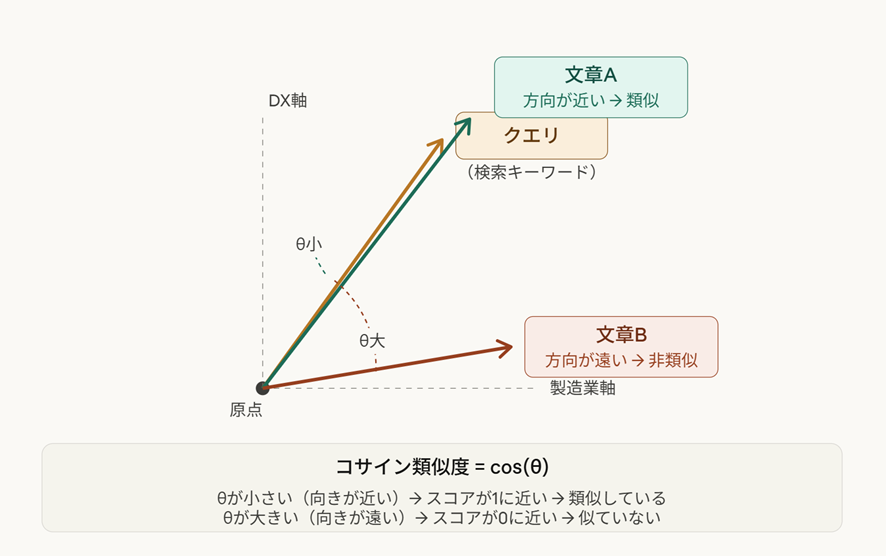

In [9]:
# コサイン類似度を計算してみよう
from sklearn.metrics.pairwise import cosine_similarity

# 3-1 で作ったベクトルをそのまま使う
similarities = cosine_similarity(query_vec, tfidf_matrix)[0]

print("クエリ「DX 製造業」との類似度：")
labels = [
    "文章A（DX推進・製造業）",
    "文章B（AI・機械学習）",
    "文章C（DX・製造業・IoT）",
]
for label, score in zip(labels, similarities):
    bar = "█" * int(score * 20)
    print(f"  {score:.3f}  {bar}  {label}")

print()
best_idx = similarities.argmax()
print(f"→ 最もクエリに近い文章：{labels[best_idx]}（スコア：{similarities[best_idx]:.3f}）")

クエリ「DX 製造業」との類似度：
  0.557  ███████████  文章A（DX推進・製造業）
  0.000    文章B（AI・機械学習）
  0.528  ██████████  文章C（DX・製造業・IoT）

→ 最もクエリに近い文章：文章A（DX推進・製造業）（スコア：0.557）


### 〈ここで確認してほしいこと〉

✅ クエリ「DX 製造業」に対して文章Aと文章Cが高いスコアになっている（「DX」「製造業」を含むため）

✅ 文章Bはスコアが 0 に近い（「AI」「機械学習」はクエリに含まれないため）

✅ `cosine_similarity(query_vec, tfidf_matrix)[0]` の `[0]` は
   「1件のクエリに対する全文章のスコア配列」を取り出している

> 💡 スコアが高い順に並べれば、それが「検索ランキング」になる。
> Step 4 の `SearchEngine.search()` はこの仕組みをクラスとして実装したものだ。

> 💡 参考動画｜コサイン類似度の概念・計算式　https://www.youtube.com/watch?v=3hz5km0XtXU

### 〈3-3：TF-IDF × ベクトル化 × コサイン類似度 ＝ 検索〉

ここまで学んだことをつなげよう。

```
【Step 2 で学んだこと】          【Step 3 で学んだこと】
─────────────────────           ─────────────────────────────
TF-IDF スコア計算                ベクトル化
（単語ごとの重要度を数値化）  →  （文章を数値の配列に変換）
                                         ↓
                                 コサイン類似度計算
                                 （クエリとページの「近さ」を 0〜1 で測る）
                                         ↓
                                 スコア降順でソート
                                         ↓
                                 検索結果（ランキング）
```

> 💡 **まとめ**：
> - **TF-IDF** ＝ 「どの単語が重要か」を数値化する
> - **ベクトル化** ＝ 文章全体を「数値の配列（矢印）」に変換する
> - **コサイン類似度** ＝ クエリとページの「矢印の向き」がどれだけ近いかを測る
>
> この 3 つを組み合わせることで、「クエリに最も関連性の高いページ」を
> 数学的に見つけ出せる。これが **TF-IDF 検索エンジンの本質** だ。

> 💡 参考動画｜形態素解析→TF-IDF→ベクトル化→コサイン類似度（コード付き）　https://www.youtube.com/watch?v=5vRyPMBOr_w


ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### ─── 演習問題 3-A ───────────────────────────────

**問題**：以下のテキストに対して「AI 機械学習」でコサイン類似度を計算してみよう。
どの文章が最も高いスコアになるか、**実行前に予想してから**確認しよう。

```python
docs = [
    "DX 推進 製造業 効率 向上",
    "AI 機械学習 業務 効率 化",
    "Python データ 分析 AI モデル 作成",
    "IoT センサー 工場 DX コスト 削減",
]
query = "AI 機械学習"
```

さらに：`query = "DX IoT"` に変えると、上位の文章はどう変わるか確認してみよう。

<details>
<summary>💡 ヒント（クリックして開く）</summary>

3-1・3-2 のコードをほぼそのまま流用できる。
`query` の値を変えて実行してみよう。

</details>

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

In [13]:
# 演習問題3-A
# コサイン類似度を計算してみよう
# ベクトル化の仕組みを確認しよう
from sklearn.feature_extraction.text import TfidfVectorizer

# サンプルテキスト
docs = [
    "DX 推進 製造業 効率 向上",
    "AI 機械学習 業務 効率 化",
    "Python データ 分析 AI モデル 作成",
    "IoT センサー 工場 DX コスト 削減",
]
query = "DX Iot"

# TF-IDF でベクトル化する
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(docs)

# クエリもベクトル化する
query_vec = vectorizer.transform([query])

# 語彙（インデックス化された単語）を確認する
feature_names = vectorizer.get_feature_names_out()
print("語彙：", feature_names)
print()

# クエリのベクトル（各単語のTF-IDFスコア）を確認する
print("クエリ「DX Iot」のベクトル（スコアが 0 でない単語）：")
for word, score in zip(feature_names, query_vec.toarray()[0]):
    if score > 0:
        print(f"  '{word}': {score:.3f}")




from sklearn.metrics.pairwise import cosine_similarity

# 3-1 で作ったベクトルをそのまま使う
similarities = cosine_similarity(query_vec, tfidf_matrix)[0]

print("クエリ「DX Iot」との類似度：")
labels = [
    "文章A（DX推進・製造業）",
    "文章B（AI・機械学習）",
    "文章C（Python・AI・データ分析）",
    "文章D（IoT・DX・工場・コスト削減）",
]
for label, score in zip(labels, similarities):
    bar = "█" * int(score * 20)
    print(f"  {score:.3f}  {bar}  {label}")

print()
best_idx = similarities.argmax()
print(f"→ 最もクエリに近い文章：{labels[best_idx]}（スコア：{similarities[best_idx]:.3f}）")

語彙： ['ai' 'dx' 'iot' 'python' 'コスト' 'センサー' 'データ' 'モデル' '作成' '分析' '削減' '効率'
 '向上' '工場' '推進' '業務' '機械学習' '製造業']

クエリ「DX Iot」のベクトル（スコアが 0 でない単語）：
  'dx': 0.619
  'iot': 0.785
クエリ「DX Iot」との類似度：
  0.237  ████  文章A（DX推進・製造業）
  0.000    文章B（AI・機械学習）
  0.000    文章C（Python・AI・データ分析）
  0.537  ██████████  文章D（IoT・DX・工場・コスト削減）

→ 最もクエリに近い文章：文章D（IoT・DX・工場・コスト削減）（スコア：0.537）


# Step 4：SearchEngineクラスの実装

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈ライブラリを使う前に仕組みを知ろう〉

- Step 2 ではTF-IDFを理解した。
- Step 3 ではベクトル化とコサイン類似度を学んだ。
- Step 4 では次の順序で実装を進める：

```
① calc_tf() / calc_idf() を自分で書く（手実装）　※Step2〜3の復習
         ↓
② scikit-learn の TfidfVectorizer を使う（ライブラリ版）
         ↓
③ cosine_similarity で文書の近さを測る（Step 3 で学んだ内容）
         ↓
④ SearchEngine クラスにまとめる（プロダクション版）
```

「なぜこのコードを書くのか」が分かった上でライブラリを使うと、
エラーが出たときに原因を特定しやすくなる。

### 〈4-1：calc_tf 関数を書いてみよう〉

Step 2 の TF 計算式をそのまま関数にする。

In [2]:
# TF（単語の出現頻度）を計算する関数

def calc_tf(text: str, word: str) -> float:
    """
    1つのテキスト内での単語の TF（出現頻度）を計算する。

    Args:
        text : 対象テキスト（スペース区切り）
        word : 調べたい単語

    Returns:
        TF スコア（0〜1 の小数）
    """
    words = text.split()         # テキストを単語リストに分解する

    if len(words) == 0:
        return 0.0               # 空のテキストは 0 を返す

    count = words.count(word)    # 対象単語の出現回数を数える
    return count / len(words)    # 出現回数 ÷ 総単語数 = TF


# 動作確認
text1 = "DX 推進 で 製造業 の 効率 が 向上 DX は 重要 な 戦略"
print(f"calc_tf(text1, 'DX')：{calc_tf(text1, 'DX'):.3f}")   # ≈ 0.154
print(f"calc_tf(text1, 'の')：{calc_tf(text1, 'の'):.3f}")   # ≈ 0.077

calc_tf(text1, 'DX')：0.154
calc_tf(text1, 'の')：0.077


### 〈ここで確認してほしいこと〉

✅ 計算結果が Step 2 の手計算（0.154, 0.077）と一致している

> ⚠️ **注意**：この実装はスペース区切りを前提にしている。
> 日本語は単語の間にスペースがないため、本来は形態素解析が必要。
> Week4のスコープではスペース区切りのテキストで進める。

### 〈4-2：calc_idf 関数を書いてみよう〉

複数のテキスト（ページのリスト）を受け取り、1つの単語の IDF を計算する。

In [4]:
import math

# IDF（逆文書頻度）を計算する関数

def calc_idf(docs: list, word: str) -> float:
    """
    複数のドキュメント（ページ）内での単語の IDF を計算する。

    Args:
        docs : テキストのリスト（各ページのテキスト）
        word : 調べたい単語

    Returns:
        IDF スコア（0 以上の小数）
    """
    # その単語が含まれるページ数を数える
    pages_with_word = sum(1 for doc in docs if word in doc.split())

    if pages_with_word == 0:
        return 0.0               # どのページにも出てこない単語は 0 を返す

    # IDF を計算する：log(総ページ数 / 含むページ数)
    return math.log(len(docs) / pages_with_word)


# 動作確認
# 日本語を単語分割するには「形態素解析ライブラリ」が必要。講義を簡素化するために英語のようにトークン別にスペースを設けた
docs = [
    "DX 推進 で 製造業 の 効率 が 向上",
    "AI 活用 で 業務 効率 化 を 進める",
    "IoT センサー で 工場 DX を 実現",
    "Python で AI モデル を 作る",
    "データ 分析 で 経営 判断 を 支援",
]

print(f"IDF（DX）  ：{calc_idf(docs, 'DX'):.3f}")      # 2ページに出現 → 中程度
print(f"IDF（の）  ：{calc_idf(docs, 'の'):.3f}")      # 1ページのみ → やや高い
print(f"IDF（効率）：{calc_idf(docs, '効率'):.3f}")    # 2ページに出現 → 中程度
print(f"IDF（AI）  ：{calc_idf(docs, 'AI'):.3f}")      # 2ページに出現 → 中程度

IDF（DX）  ：0.916
IDF（の）  ：1.609
IDF（効率）：0.916
IDF（AI）  ：0.916


### 〈ここで確認してほしいこと〉

✅ `math.log()` で対数を計算できる。すなわちIDFを計算している

✅ 出現ページ数が多いほど IDF が低くなる傾向が確認できた

> 💡 **「の」の IDF が「DX」より低いのはなぜ？**
>
> 今回のサンプルコーパスは5件しかないため「の」は1件にしか出現せず、
> IDF が意外と高く見える場合がある。
> 実際の数十〜数百件のデータでは「の」はほぼ全ページに出現するため IDF ≒ 0 に近づく。
> 「コーパスが大きくなるほど結果が安定する」と覚えておこう。

### 〈4-3：TF-IDFスコアで検索ランキングを作ろう〉

`calc_tf` と `calc_idf` を組み合わせて、検索関数を作る。
これが「手実装版 TF-IDF 検索エンジン」だ。

In [5]:
# TF-IDF ベースの検索関数（手実装版）

def search_tfidf_manual(query: str, docs: list) -> list:
    """
    TF-IDF スコアでドキュメントをランキングする（手実装版）。

    Args:
        query : 検索クエリ（スペース区切りで複数単語可）
        docs  : テキストのリスト

    Returns:
        スコア降順のランキングリスト
    """
    results = []

    for i, doc in enumerate(docs):
        # クエリを単語に分解する
        query_words = query.split()

        # クエリの各単語について TF-IDF スコアを計算して合計する
        score = 0.0
        for word in query_words:
            tf = calc_tf(doc, word)
            idf = calc_idf(docs, word)
            score += tf * idf           # TF × IDF を積み上げる

        if score > 0:
            results.append({"index": i, "score": round(score, 4), "text": doc[:40]})

    # スコアの高い順に並べる
    results.sort(key=lambda x: x["score"], reverse=True)
    return results


# 動作確認：「DX 効率」で検索
docs_pages = [
    "DX 推進 で 製造業 の 効率 が 向上 DX は 重要 な 戦略",
    "AI 活用 で 業務 効率 化 を 進める ツール の 導入",
    "IoT センサー で 工場 DX を 実現 コスト 削減",
    "Python で AI モデル を 作る データ サイエンス 入門",
    "データ 分析 で 経営 判断 を 支援 BI ツール 活用",
]

results = search_tfidf_manual("DX 効率", docs_pages)
print("「DX 効率」での検索結果：")
for r in results:
    print(f"  スコア {r['score']:.4f}：{r['text']}...")

「DX 効率」での検索結果：
  スコア 0.2115：DX 推進 で 製造業 の 効率 が 向上 DX は 重要 な 戦略...
  スコア 0.1018：IoT センサー で 工場 DX を 実現 コスト 削減...
  スコア 0.0833：AI 活用 で 業務 効率 化 を 進める ツール の 導入...


### 〈4-4：scikit-learn の TfidfVectorizer を使おう〉

手実装で仕組みが分かった。次はライブラリを使ってより高精度に実装する。

`scikit-learn` の `TfidfVectorizer` は：
- スペース区切りでなくても単語を分解できる
- バイグラム（2単語の組み合わせ）も考慮できる
- 大量ページでも高速に処理できる

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# TfidfVectorizer でインデックスを構築する
# 日本語を単語分割するには「形態素解析ライブラリ」が必要。講義を簡素化するために英語のようにトークン別にスペースを設けた
docs_pages = [
    "DX 推進 で 製造業 の 効率 が 向上 DX は 重要 な 戦略",
    "AI 活用 で 業務 効率 化 を 進める ツール の 導入",
    "IoT センサー で 工場 DX を 実現 コスト 削減",
    "Python で AI モデル を 作る データ サイエンス 入門",
    "データ 分析 で 経営 判断 を 支援 BI ツール 活用",
]

# TF-IDF ベクトライザーを作成する
vectorizer = TfidfVectorizer(
    max_features=5000,   # 語彙の最大数
    ngram_range=(1, 2),  # ユニグラム（1語）とバイグラム（2語の組み合わせ）
    min_df=1,            # 最低1ページに出てくる単語のみ
    max_df=0.95,         # 95%以上のページに出てくる単語は除外
    sublinear_tf=True    # TF の対数スケーリング（大きすぎる値を抑える）
)

# 全ページのテキストをベクトル化する（fit_transform）
tfidf_matrix = vectorizer.fit_transform(docs_pages)
print(f"マトリックスの形状：{tfidf_matrix.shape}")  # (ページ数, 語彙数)
print(f"語彙数：{len(vectorizer.get_feature_names_out())} 語")

# 検索クエリをベクトル化して類似度を計算する（transform のみ）
query = "DX 効率"
query_vec = vectorizer.transform([query])
scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

print()
print("「DX 効率」のコサイン類似度スコア：")
for i, score in enumerate(scores):
    if score > 0:
        print(f"  ページ{i+1}（スコア {score:.4f}）：{docs_pages[i][:40]}...")

マトリックスの形状：(5, 62)
語彙数：62 語

「DX 効率」のコサイン類似度スコア：
  ページ1（スコア 0.4032）：DX 推進 で 製造業 の 効率 が 向上 DX は 重要 な 戦略...
  ページ2（スコア 0.1675）：AI 活用 で 業務 効率 化 を 進める ツール の 導入...
  ページ3（スコア 0.1604）：IoT センサー で 工場 DX を 実現 コスト 削減...


### 〈手実装とライブラリの結果を比べよう〉

✅ 順位の傾向が似ている（どちらも「DX」を多く含むページが上位）

✅ ライブラリ版の方がバイグラムも考慮するため微妙にスコアが異なる

✅ `cosine_similarity`（コサイン類似度）の仕組みは Step 3 で詳しく学んだ

✅ コサイン類似度は文章の長さに左右されない → 長短のページを公平に比較できる

### 〈4-5：SearchEngine クラスに発展させよう〉

関数を **クラス** にまとめると、次のメリットがある：
- インデックス（TF-IDFマトリックス）を一度だけ作れば使いまわせる
- `build_index()` → `search()` という自然な使い方ができる
- チームで分担しやすい（ランキング担当が管理するファイルになる）

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import math
from datetime import datetime

class SearchEngine:
    """TF-IDFベースの検索エンジン（ranking.py の本体）"""

    def __init__(self):
        # TF-IDF ベクトライザーを初期化する
        self.vectorizer = TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2),  # ユニグラム（1語）とバイグラム（隣り合う2語のまとまり）を両方使う
            min_df=1,
            max_df=0.95,
            sublinear_tf=True    # TF の対数スケーリング
        )
        self.tfidf_matrix = None  # インデックス（後で構築）
        self.pages = []           # 元のページデータを保持
        self.is_fitted = False    # インデックスが構築済みかのフラグ

    def build_index(self, pages: list):
        """
        全ページの TF-IDF インデックスを構築する。

        Args:
            pages: ページ情報の辞書リスト
        """
        if not pages:
            return

        self.pages = pages

        # 各ページの「検索対象テキスト」を組み立てる
        # タイトル・説明・キーワードに重みを付けるため、文字列を繰り返す
        corpus = []
        for p in pages:
            # keywords がカンマ区切り文字列の場合はリストに変換する
            kw = p.get("keywords", "") or ""
            if isinstance(kw, str):
                kw_list = [k.strip() for k in kw.split(",") if k.strip()]
            else:
                kw_list = kw

            # 重みづけを実施。タイトルは 3倍、説明は 2倍、キーワードは 2倍の重みを付ける
            text = " ".join([
                (p.get("title", "") + " ") * 3,        # タイトルは3倍
                (p.get("description", "") + " ") * 2,  # 説明は2倍
                (p.get("full_text", "") + " "),        # 本文
                (" ".join(kw_list) + " ") * 2,         # キーワードは2倍
            ])
            corpus.append(text)

        # TF-IDF マトリックスを構築する
        self.tfidf_matrix = self.vectorizer.fit_transform(corpus)
        self.is_fitted = True
        print(f"インデックス構築完了：{len(pages)} ページ")

    def search(self, query: str, top_n: int = 20) -> list:
        """
        TF-IDF ベースの検索を実行する。

        Args:
            query : 検索クエリ
            top_n : 返す結果の最大数

        Returns:
            スコア付きの検索結果リスト
        """
        if not self.is_fitted or not query.strip():
            return []

        # クエリをベクトル化してコサイン類似度を計算する（Step 3 で学んだ内容）
        query_vec = self.vectorizer.transform([query])
        similarities = cosine_similarity(query_vec, self.tfidf_matrix)[0]

        # 閾値以上のページだけ結果に含める
        results = []
        for idx, base_score in enumerate(similarities):
            if base_score > 0.01:
                page = self.pages[idx].copy()

                # 追加スコアリングで最終スコアを計算する
                final_score = self._calculate_final_score(page, base_score, query)

                # スコアをパーセント表示用に変換する
                page["relevance_score"] = round(float(final_score) * 100, 1)
                page["base_score"] = round(float(base_score) * 100, 1)
                results.append(page)

        # スコアの高い順に並べて top_n 件を返す
        results.sort(key=lambda x: x["relevance_score"], reverse=True)
        return results[:top_n]

    def _calculate_final_score(self, page: dict, base_score: float, query: str) -> float:
        """
        複数の要素を組み合わせて最終スコアを計算する（内部メソッド）。
        Args:
            page: ページ情報
            base_score: TF-IDFベーススコア
            query: 検索クエリ

        Returns:
            最終スコア
        """
        score = base_score
        query_lower = query.lower()

        # 1. タイトルマッチボーナス
        title = page.get("title", "").lower()
        if query_lower == title:
            score *= 1.8          # 完全一致：+80%
        elif query_lower in title:
            score *= 1.4          # 部分一致：+40%

        # 2. キーワードマッチボーナス
        keywords = page.get("keywords", [])

        if isinstance(keywords, str):
            keywords = keywords.split(",")

        keywords_lower = [k.strip().lower() for k in keywords]

        if query_lower in keywords_lower:
            score *= 1.3  # キーワード一致：+30%

        # 3. 新鮮度ボーナス（90日以内のページは最大 +20%）
        crawled_at = page.get("crawled_at", "")
        if crawled_at:
            try:
                crawled = datetime.fromisoformat(crawled_at.replace("Z", "+00:00"))
                days_old = (datetime.now() - crawled.replace(tzinfo=None)).days
                if days_old <= 90:
                    recency_bonus = 1 + (0.2 * (90 - days_old) / 90)
                    score *= recency_bonus
            except Exception:
                pass

        # 4. 文字数による調整
        word_count = page.get("word_count", 0)
        if word_count < 50:
            score *= 0.7          # 短すぎるページは減点
        elif word_count > 10000:
            score *= 0.85         # 長すぎるページは少し減点

        return score


# ── 動作確認 ────────────────────────────────────────────────

# テスト用ページデータ
sample_pages = [
    {"title": "DX戦略レポート2024", "description": "製造業のDX推進について解説",
     "full_text": "DX 推進 で 製造業 の 効率 が 向上 DX は 重要 な 戦略 デジタル 変革",
     "keywords": "DX,製造業,デジタル変革", "word_count": 50,
     "crawled_at": "2024-01-15T10:00:00"},
    {"title": "AI活用ガイド", "description": "業務効率化のためのAI導入",
     "full_text": "AI 活用 で 業務 効率 化 を 進める ツール の 導入 機械 学習",
     "keywords": "AI,機械学習,業務効率化", "word_count": 45,
     "crawled_at": "2024-02-20T15:00:00"},
    {"title": "IoTセンサー活用事例", "description": "工場のIoT化事例",
     "full_text": "IoT センサー で 工場 DX を 実現 コスト 削減 リアルタイム モニタリング",
     "keywords": "IoT,工場,DX,センサー", "word_count": 60,
     "crawled_at": "2024-03-01T09:00:00"},
]

# SearchEngine を使ってみる
engine = SearchEngine()
engine.build_index(sample_pages)

results = engine.search("Iot")
print("\n「Iot」での検索結果：")
for i, r in enumerate(results, 1):
    medal = ["🥇", "🥈", "🥉"][i-1] if i <= 3 else str(i)
    print(f"  {medal} {r['title']}（relevance: {r['relevance_score']} / base: {r['base_score']}）")

インデックス構築完了：3 ページ

「Iot」での検索結果：
  🥇 IoTセンサー活用事例（relevance: 52.4 / base: 28.8）


### 〈ここで確認してほしいこと〉

✅ `build_index()` でインデックスを1回作れば `search()` で何度も使いまわせる

✅ `relevance_score`（最終スコア）と `base_score`（TF-IDF の元スコア）の2種類がある

✅ タイトルに「DX」が含まれるページが高いスコアになっている

✅ スコアが0.01未満のページは除外し、無関係なページが表示される問題を防いでいる（`search()` メソッド内部で `base_score >= 0.01` のフィルター）


**`relevance_score` と `base_score` の違い：**

| スコア | 意味 |
|--------|------|
| `base_score` | TF-IDF のコサイン類似度のみ |
| `relevance_score` | base + タイトルマッチ + 新鮮度 + 文字数ボーナスを加味した最終スコア |

アプリ画面では両方を表示して「なぜこのページが1位なのか」を分かりやすくする。



> 💡 **検索ロジック｜独自の重みづけ**
>
> `_calculate_final_score` で「タイトルマッチ・新鮮度・文字数」などで重みづけをしたロジックとしている。
> この関数を変更または新たな要素を加えることで、独自の検索ロジックを作ることができる。　

### ─── 演習問題 4-A ───────────────────────────────

**問題**：上記のコードで検索クエリを変えて、ランキングがどう変わるか試してみよう。

例：
- `"AI 機械学習"` で検索したとき、1位はどのページになるか？
- `"IoT"` で検索したとき、スコアはどう変わるか？

さらに：`_calculate_final_score` の**タイトルマッチボーナス**を `1.4` から `2.0` に変えると、
結果はどう変わるか確認してみよう。

<details>
<summary>💡 ヒント（クリックして開く）</summary>

```python
results = engine.search("AI 機械学習")
for r in results:
    print(r["title"], r["relevance_score"])
```

</details>

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈4-6：シングルトンインスタンスで SearchEngine を管理しよう〉

Step 4-5 では `engine = SearchEngine()` と直接インスタンスを作成した。
しかし Streamlit アプリでは「毎回 `SearchEngine` を作ると毎回インデックスを再構築してしまう」という問題がある。

これを解決するのが **シングルトンパターン** だ：
「プログラム全体で1つのインスタンスだけを使いまわす」設計。

```
初回呼び出し：_engine が None → 新しく SearchEngine() を作る
2回目以降  ：_engine が存在する → 既存のものをそのまま返す
```

`@st.cache_resource` と組み合わせることで、Streamlit が再実行されても
インデックスが保持され、検索が高速になる。

In [11]:
from typing import List

# シングルトンインスタンス（モジュールレベルで保持する）
_engine = None

def get_engine() -> SearchEngine:
    """検索エンジンのシングルトンを取得する"""
    global _engine
    if _engine is None:
        _engine = SearchEngine()
    return _engine

def rebuild_index(pages: List[dict]):
    """インデックスを再構築する（新しいページが追加されたときに呼び出す）"""
    engine = get_engine()
    engine.build_index(pages)

# 動作確認
engine2 = get_engine()
engine3 = get_engine()
print(f"同じインスタンス？ {engine2 is engine3}")  # True になるはず
print("→ get_engine() は常に同じ SearchEngine を返す")

同じインスタンス？ True
→ get_engine() は常に同じ SearchEngine を返す


# Step 5：DB設計と移行

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈Step 4 → 5 → 6 の流れ〉

```
Step 4 で作った SearchEngine が「どのデータ」を読み込むか？
    ↓
Step 5 で DB の構造を設計し、データを永続化する仕組みを作る
    ↓
Step 6 でその DB をアプリへ実装する
```

### 〈week3（v0.2） との DB 設計の違い〉

| 比較項目 | week3（v0.2）/1テーブル | week4（v1.0）/4テーブル |
|----------|-----------------|-----------------|
| テーブル数 | 1（pages） | 4（pages/keywords/search_logs/click_logs） |
| 重複対策 | なし | UNIQUE 制約 + INSERT OR REPLACE |
| 検索ログ（発展） | なし | search_logs テーブルに記録 |
| 定義ファイル | app.py の中に SQL 文字列 | schema.sql として独立 |

> 💡 テーブルを分けると「何のデータか」が明確になる。
> ページのデータと検索のログは別の概念 → 別のテーブル、というのが DB 設計の基本。

> 💡 ログは発展課題用に仕込んである
> 検索ログ、クリックログというテーブルを仕込んであるため、発展課題として活用可能。

### 〈5-1：schema.sql を書いてみよう〉

SQL の定義をファイルに分離する理由：
- `database.py` のコードがスッキリする
- DB の構造を SQL ファイルだけ見れば把握できる
- チームで DB 担当が管理しやすくなる

In [12]:
# schema.sql の内容を Python 文字列として定義する

schema_sql = """-- schema.sql
-- Tech0 Search v1.0 データベース設計

-- pagesテーブル（メイン）
-- UNIQUE 制約：同じ URL は重複して登録できない
CREATE TABLE IF NOT EXISTS pages (
    id          INTEGER PRIMARY KEY AUTOINCREMENT,
    url         TEXT NOT NULL UNIQUE,
    title       TEXT NOT NULL,
    description TEXT,
    full_text   TEXT,
    author      TEXT,
    category    TEXT,
    word_count  INTEGER DEFAULT 0,
    crawled_at  DATETIME,
    created_at  DATETIME DEFAULT CURRENT_TIMESTAMP,
    updated_at  DATETIME DEFAULT CURRENT_TIMESTAMP
);

-- keywordsテーブル（TF-IDFスコア保存）
-- page_id が削除されたら自動的にキーワードも削除される（ON DELETE CASCADE）
CREATE TABLE IF NOT EXISTS keywords (
    id          INTEGER PRIMARY KEY AUTOINCREMENT,
    page_id     INTEGER NOT NULL,
    keyword     TEXT NOT NULL,
    tf_score    REAL DEFAULT 0.0,
    tfidf_score REAL DEFAULT 0.0,
    FOREIGN KEY (page_id) REFERENCES pages(id) ON DELETE CASCADE
);

-- 検索ログテーブル（発展用）
CREATE TABLE IF NOT EXISTS search_logs (
    id            INTEGER PRIMARY KEY AUTOINCREMENT,
    query         TEXT NOT NULL,
    results_count INTEGER DEFAULT 0,
    user_id       TEXT,
    searched_at   DATETIME DEFAULT CURRENT_TIMESTAMP
);

-- クリックログテーブル（発展用）
CREATE TABLE IF NOT EXISTS click_logs (
    id            INTEGER PRIMARY KEY AUTOINCREMENT,
    search_log_id INTEGER,
    page_id       INTEGER NOT NULL,
    position      INTEGER,
    clicked_at    DATETIME DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (search_log_id) REFERENCES search_logs(id),
    FOREIGN KEY (page_id) REFERENCES pages(id)
);

-- インデックス作成（検索を高速化する）
CREATE INDEX IF NOT EXISTS idx_keyword    ON keywords(keyword);
CREATE INDEX IF NOT EXISTS idx_page_id    ON keywords(page_id);
CREATE INDEX IF NOT EXISTS idx_search_query ON search_logs(query);
CREATE INDEX IF NOT EXISTS idx_search_date  ON search_logs(searched_at);
"""

# schema.sql ファイルに書き出す
with open("schema.sql", "w", encoding="utf-8") as f:
    f.write(schema_sql)

print("schema.sql を作成しました")

schema.sql を作成しました


### 〈schema.sqlの補足〉

✅ `UNIQUE` 制約：同じ URL のページを2回 INSERT しようとするとエラーになる

✅ `FOREIGN KEY ... ON DELETE CASCADE`：ページを削除するとキーワードも自動削除

✅ `CREATE INDEX`：キーワードや日付で検索するときに高速化される

✅ `search_log``click_logs` テーブルは発展課題で必要に応じて活用（今は定義だけ）

### 〈5-2：database.py を作ろう〉

DB への接続・初期化・データの取得・保存を1つのファイルにまとめる。
これが「DB担当」の中心ファイル。

In [13]:
import sqlite3
from pathlib import Path
from datetime import datetime

# DB ファイルのパス（data/ サブフォルダに保存する）
DB_PATH = Path("data/tech0_search.db")

def get_connection():
    """
    DB への接続を取得する。

    row_factory を設定することで、行データを辞書のように扱える。
    data/ フォルダが存在しない場合は自動で作成する。
    """
    DB_PATH.parent.mkdir(exist_ok=True)   # data/ フォルダがなければ作る
    conn = sqlite3.connect(str(DB_PATH))
    conn.row_factory = sqlite3.Row        # 行データを辞書のように扱う
    return conn

def init_db():
    """
    schema.sql を読み込んで DB を初期化する。

    CREATE TABLE IF NOT EXISTS を使っているので、
    すでにテーブルが存在する場合は何もしない。
    """
    conn = get_connection()
    with open("schema.sql", "r", encoding="utf-8") as f:
        conn.executescript(f.read())    # SQL ファイルをまとめて実行する
    conn.commit()
    conn.close()
    print("DB を初期化しました（data/tech0_search.db）")

# 動作確認
init_db()

DB を初期化しました（data/tech0_search.db）


### 〈ここで確認してほしいこと〉

✅ `get_connection()` でDBへ接続している

✅ `init_db()` で`schema.sql`を読み込んで DB を初期化している

✅ `data/tech0_search.db` ファイルが生成されていることを確認しよう

### 〈5-3：INSERT OR REPLACE でページを登録しよう〉

`INSERT OR REPLACE` は「同じ URL のデータがあれば上書き、なければ新規追加」する。
week3 の重複チェック（`SELECT COUNT(*) ...`）より効率的だ。

In [14]:
def insert_page(page: dict) -> int:
    """
    ページ情報を DB に登録する。

    INSERT OR REPLACE：同じ URL のデータがあれば上書き、なければ新規追加する。
    これにより「同じページを再クロールしたときに最新データに更新できる」。

    Args:
        page: ページ情報の辞書（crawl_url() の返り値と同形式）

    Returns:
        登録された行の id
    """
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("""
        INSERT OR REPLACE INTO pages
            (url, title, description, full_text, author, category, word_count, crawled_at)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        page["url"],
        page["title"],
        page.get("description", ""),
        page.get("full_text", ""),
        page.get("author", ""),
        page.get("category", ""),
        page.get("word_count", 0),
        page.get("crawled_at", datetime.now().isoformat()),
    ))

    page_id = cursor.lastrowid    # 登録された行の id を取得する
    conn.commit()
    conn.close()
    return page_id


def get_all_pages() -> list:
    """全ページを登録日時の新しい順で取得する。"""
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM pages ORDER BY created_at DESC")
    rows = cursor.fetchall()
    conn.close()
    return [dict(row) for row in rows]    # sqlite3.Row を辞書に変換して返す


# 動作確認：テストデータを登録する
test_pages = [
    {"url": "https://example.com/dx-report",
     "title": "DX戦略レポート2024",
     "description": "製造業のDX推進について解説した報告書",
     "full_text": "DX 推進 で 製造業 の 効率 が 向上 デジタル 変革 事例",
     "keywords": "DX,製造業,デジタル変革",
     "word_count": 150,
     "crawled_at": "2024-01-15T10:00:00"},
    {"url": "https://example.com/ai-guide",
     "title": "AI活用ガイド",
     "description": "業務効率化のためのAI導入ガイド",
     "full_text": "AI 活用 で 業務 効率 化 を 進める 機械 学習 ツール",
     "keywords": "AI,機械学習,業務効率化",
     "word_count": 120,
     "crawled_at": "2024-02-20T15:00:00"},
]

for p in test_pages:
    pid = insert_page(p)
    print(f"登録完了：id={pid}  {p['title']}")

# 登録されたデータを確認する
all_pages = get_all_pages()
print(f"\n現在の登録ページ数：{len(all_pages)} 件")


def log_search(query: str, results_count: int, user_id: str = None) -> int:
    """
    検索ログを記録する（Step7発展課題で実装予定）
    現在はスタブ（空の関数）として定義しています。
    Step7で実際の記録処理を実装してください。
    """
    pass  # Step7で実装してください

登録完了：id=19  DX戦略レポート2024
登録完了：id=20  AI活用ガイド

現在の登録ページ数：20 件


### 〈ここで確認してほしいこと〉

✅ `INSERT OR REPLACE` は「重複チェック不要」で簡潔に書ける（しかし注意点もあり、下部参照）

✅ `insert_page(page: dict) -> int:` でページ情報をDBに登録している

✅ `get_all_pages() -> list:` で全ページを登録日時の新しい順で取得している

**`INSERT` と `INSERT OR REPLACE` の違い：**

| コマンド | 同じ URL が既存の場合 |
|----------|---------------------|
| `INSERT` | エラーになる（UNIQUE 制約違反） |
| `INSERT OR REPLACE` | 既存のデータを削除して新規追加 |


>
> ⚠️注意｜ **このセルを複数回実行すると id が増えます**
>
> `INSERT OR REPLACE` は「削除してから再挿入」するため、実行のたびに id が増加します。
> `data/tech0_search.db` はノートブックと同じフォルダに**ファイルとして残り続ける**ため、
> リセットしたい場合は次の方法を使ってください：
> ```python
> import os
> os.remove("data/tech0_search.db")  # DB ファイルを削除して最初からやり直す
> ```

# Step 6：app.py v1.0 に統合する

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈ここまで作ったパーツをすべてつなぐ〉

```
database.py  ──┐
ranking.py   ──┼──→  app.py v1.0（Streamlit）
crawler.py   ──┘
```

Step 4〜5 で作った部品を `app.py` から呼び出す。
これが「フロント担当」の最後の仕事だ。

### 〈6-1：app.py に各モジュールを統合する〉

Step 4 で **検索エンジン（ranking.py）** を、Step 5 で **DB操作（database.py）** を作った。
ここでは、それらの部品を **app.py の中で使えるようにつなぐ** 方法を学ぶ。

```
Step 4 で作った → ranking.py（SearchEngine クラス）
Step 5 で作った → database.py（DB の読み書き）
Week3 から流用  → crawler.py（Web クロール）
                       ↓
               app.py で全部つなぐ！
```

> 💡 「部品を作ること」と「部品をつなぐこと」は別の作業だ。
> このステップでは、つなぐ方法（= **モジュールの統合**）を学ぶ。

### 〈① モジュールとは何か〉

**モジュール** とは、`.py` ファイル1つのことだ。
関連する関数をひとつのファイルにまとめておくと、他のファイルから「借りて使う」ことができる。

| モジュール | ファイル | 何をする部品か |
|-----------|---------|-------------|
| database | `database.py` | DBへの保存・取得（冷蔵庫係） |
| ranking | `ranking.py` | TF-IDF 検索（シェフ） |
| crawler | `crawler.py` | Web からデータ収集（買い物係） |

> 💡 **料理キットで考えると**
>
> `database.py`（冷蔵庫係）が食材を管理し、
> `crawler.py`（買い物係）が新しい食材を仕入れ、
> `ranking.py`（シェフ）が料理（= 検索結果）を作る。
> `app.py` はそれを **お客さん（ユーザー）に出すホールスタッフ** だ。

### 〈② import の書き方〉

別の `.py` ファイルの関数を使いたいときは **`import`** を使う。

**書き方は2種類ある：**

```python
# パターン①：モジュールごと読み込む
import database
database.init_db()  # モジュール名.関数名() で呼び出す

# パターン②：使いたい関数だけ読み込む（今回はこちら）
from database import init_db, get_all_pages
init_db()           # 関数名だけで呼び出せる（短くて読みやすい）
```

> 💡 `from XX import YY` の読み方：
> 「`XX` というファイルの中から `YY` という関数を持ってくる」

**今回 app.py で使う import 文：**

```python
from database import init_db, get_all_pages, insert_page, log_search　　# log_searchは発展用に残してある
from ranking  import get_engine, rebuild_index
from crawler  import crawl_url
```

ファイルが同じフォルダにあれば、このように書くだけで使えるようになる。

In [15]:
# import が正しく動作するか確認しよう
# ※ このセルは database.py・ranking.py・crawler.py が同じフォルダにある前提で動作する（そうでないとエラーがでます）

from database import init_db, get_all_pages, insert_page, log_search
from ranking  import get_engine, rebuild_index
from crawler  import crawl_url

# 各関数が読み込めているか確認する
print("✅ database.py から読み込んだ関数：")
print(f"   init_db     → {init_db}")
print(f"   get_all_pages → {get_all_pages}")
print(f"   insert_page → {insert_page}")
print(f"   log_search  → {log_search}")

print("✅ ranking.py から読み込んだ関数：")
print(f"   get_engine    → {get_engine}")
print(f"   rebuild_index → {rebuild_index}")

print("✅ crawler.py から読み込んだ関数：")
print(f"   crawl_url → {crawl_url}")

print("→ エラーが出なければ統合の準備完了！")

✅ database.py から読み込んだ関数：
   init_db     → <function init_db at 0x000002232B6AB420>
   get_all_pages → <function get_all_pages at 0x000002232B6AB560>
   insert_page → <function insert_page at 0x000002232B6AB4C0>
   log_search  → <function log_search at 0x000002232B6AB600>
✅ ranking.py から読み込んだ関数：
   get_engine    → <function get_engine at 0x000002232B6A8B80>
   rebuild_index → <function rebuild_index at 0x000002232B6AB7E0>
✅ crawler.py から読み込んだ関数：
   crawl_url → <function crawl_url at 0x000002232C854CC0>
→ エラーが出なければ統合の準備完了！


### 〈③ 今回の3モジュールの役割分担と統合手順〉

app.py の中での呼び出し順序は以下の通り：

```
① 起動時    init_db()              → DB のテーブルを準備する
② 起動時    pages = get_all_pages() → DB から全ページを取得する
③ 起動時    rebuild_index(pages)    → TF-IDF インデックスを構築する
④ 検索時    engine.search(query)    → 検索クエリに対してランキングを返す
⑤ クロール時 crawl_url(url)         → Web ページを取得してデータを抽出する
⑥ 登録時    insert_page(result)     → クロール結果を DB に保存する
```

**データの流れ：**

```
URL 入力
  ↓
crawler.py：crawl_url()      ← Web からデータ取得
  ↓
database.py：insert_page()   ← DB に保存
  ↓
ranking.py：rebuild_index()  ← TF-IDF インデックス更新
  ↓
ranking.py：engine.search()  ← 検索クエリに対してスコア計算
  ↓
app.py：検索結果を画面に表示
```

> 💡 **ポイント**：app.py は自分では「考えない」。
> 各モジュールに作業を依頼して、結果をユーザーに見せるだけ。

### 〈ここで確認してほしいこと〉

✅ モジュールとは `.py` ファイル1つのことだと言える

✅ `from XX import YY` の意味（どのファイルの・何を・持ってくる）が言える

✅ 今回の3つのモジュールがそれぞれ何をするか答えられる

✅ import のエラーが出た場合は「ファイルが同じフォルダにあるか」を確認する

### 〈演習問題 6-A〉

**問：** app.py で `insert_page` 関数を使いたい。正しい import 文を書いてください。

```python
# ここに import 文を書いてみよう
from _______ import _______
```

<details>
<summary>💡 ヒント（クリックして開く）</summary>

> 💡 **ヒント**：`insert_page` 関数はどのファイルに定義されているか確認しよう（Step 5 を振り返ると見つかる）。

**確認：** 以下のコードが動けば正解だ。

```python
test_page = {
    "url": "https://example.com",
    "title": "テスト",
    "description": "",
    "full_text": "",
    "word_count": 0,
    "crawled_at": "2024-01-01T00:00:00"
}
insert_page(test_page)
print("✅ insert_page が使えた！")
```

</details>
ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー


In [18]:
# 演習問題6-A


test_page = {
    "url": "https://example.com",
    "title": "テスト",
    "description": "",
    "full_text": "",
    "word_count": 0,
    "crawled_at": "2024-01-01T00:00:00"
}
insert_page(test_page)
print("✅ insert_page が使えた！")

✅ insert_page が使えた！


### 〈6-2：@st.cache_resource とは〉

`@st.cache_resource` は「重い処理の結果をキャッシュする」デコレータだ。

**なぜ必要か：**
Streamlit はユーザーが操作するたびにスクリプト全体を再実行する。
`SearchEngine.build_index()` は全ページを読み込んでベクトル化するため、
毎回実行すると遅くなってしまう。

**解決策：**
`@st.cache_resource` を付けた関数の返り値は、
アプリが動いている間は**一度だけ実行されてキャッシュされる**。

```python
@st.cache_resource
def load_and_index():
    pages = get_all_pages()
    if pages:
        rebuild_index(pages)  # 一度だけ実行される
    return pages
```

> 💡 「ページを追加したのに検索結果に出てこない」ときは
> `st.cache_resource.clear()` でキャッシュをリセットする。

### 〈サンプルコード｜app.py〉
ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

> 💡 **参考** app.py に統合したサンプルコード。（下部をクリックすると展開します）

<details>
<summary>UI改善はチーム活動として対象のため、参考コードに引っ張られない開発を期待！（学習のために開かずに自身で統合するのもあり！）</summary>

```python
# =============================================================
# app.py — Tech0 Search v1.0（完成版コード）
# ⚠️ このセルは Streamlit アプリ用のコードです。Jupyter では実行できません。
#    このコードを app.py ファイルとして保存し、streamlit run app.py で起動してください。
# =============================================================

import streamlit as st
from database import init_db, get_all_pages, insert_page, log_search 　#log_searchは発展用
from ranking import get_engine, rebuild_index
from crawler import crawl_url

# アプリ起動時に DB を初期化する（テーブルが未作成なら作る）
init_db()

st.set_page_config(
    page_title="Tech0 Search v1.0",
    page_icon="🔍",
    layout="wide"
)

# ── キャッシュ付きインデックス構築 ─────────────────────────────
@st.cache_resource
def load_and_index():
    """全ページを DB から読み込み TF-IDF インデックスを構築する。
    @st.cache_resource により、アプリ起動中は一度だけ実行される。"""
    pages = get_all_pages()
    if pages:
        rebuild_index(pages)
    return pages

pages = load_and_index()
engine = get_engine()

# ── ヘッダー ──────────────────────────────────────────────────
st.title("🔍 Tech0 Search v1.0")
st.caption("PROJECT ZERO — 社内ナレッジ検索エンジン【TF-IDFランキング搭載】")

with st.sidebar:
    st.header("DB の状態")
    st.metric("登録ページ数", f"{len(pages)} 件")
    if st.button("🔄 インデックスを更新"):
        st.cache_resource.clear()
        st.rerun()

# ── タブ ──────────────────────────────────────────────────────
tab_search, tab_crawl, tab_list = st.tabs(
    ["🔍 検索", "🤖 クローラー", "📋 一覧"]
)

# ── 検索タブ ───────────────────────────────────────────────────
with tab_search:
    st.subheader("キーワードで検索")

    col_search, col_options = st.columns([3, 1])
    with col_search:
        query = st.text_input("🔍 キーワードを入力", placeholder="例: DX, IoT, 製造業",
                              label_visibility="collapsed")
    with col_options:
        top_n = st.selectbox("表示件数", [10, 20, 50], index=0)

    if query:
        results = engine.search(query, top_n=top_n)
        log_search(query, len(results))    # 検索するたびに自動記録

        st.markdown(f"**📊 検索結果：{len(results)} 件**（TF-IDFスコア順）")
        st.divider()

        if results:
            for i, page in enumerate(results, 1):
                with st.container():
                    col_rank, col_title, col_score = st.columns([0.5, 4, 1])
                    with col_rank:
                        # 上位3件にはメダルを表示する
                        medal = ["🥇", "🥈", "🥉"][i - 1] if i <= 3 else str(i)
                        st.markdown(f"### {medal}")
                    with col_title:
                        st.markdown(f"### {page['title']}")
                    with col_score:
                        # relevance_score（最終スコア）と base_score（TF-IDFのみ）を両方表示
                        st.metric("スコア", f"{page['relevance_score']}",
                                  delta=f"基準: {page['base_score']}")

                    desc = page.get("description", "")
                    if desc:
                        st.markdown(f"*{desc[:200]}{'...' if len(desc) > 200 else ''}*")

                    kw = page.get("keywords", "") or ""
                    if kw:
                        kw_list = [k.strip() for k in kw.split(",") if k.strip()][:5]
                        tags = " ".join([f"`{k}`" for k in kw_list])
                        st.markdown(f"🏷️ {tags}")

                    col1, col2, col3, col4 = st.columns(4)
                    with col1: st.caption(f"👤 {page.get('author', '不明') or '不明'}")
                    with col2: st.caption(f"📊 {page.get('word_count', 0)} 語")
                    with col3: st.caption(f"📁 {page.get('category', '未分類') or '未分類'}")
                    with col4: st.caption(f"📅 {(page.get('crawled_at', '') or '')[:10]}")

                    st.markdown(f"🔗 [{page['url']}]({page['url']})")
                    st.divider()
        else:
            st.info("該当するページが見つかりませんでした")

# ── クローラータブ ─────────────────────────────────────────────
import re

if "crawl_results" not in st.session_state:
    st.session_state.crawl_results = []

with tab_crawl:
    st.subheader("🤖 自動クローラー")
    st.caption("URLを入力してクロールし、インデックスに登録する")

    crawl_url_input = st.text_area(
        "クロール対象URL",
        placeholder="URLを改行またはスペース区切りで入力してください",
        height=150
    )

    if st.button("🤖 クロール実行", type="primary"):
        if crawl_url_input:
            raw_parts = re.split(r'[\s]+', crawl_url_input.strip())
            urls = [p for p in raw_parts if p.startswith(("http://", "https://"))]

            if not urls:
                st.error("有効なURLが見つかりませんでした")
            else:
                st.write(f"🔗 {len(urls)}件のURLを処理します")

                st.session_state.crawl_results = []

                for url in urls:
                    with st.spinner(f"クロール中: {url}"):
                        result = crawl_url(url)

                    if result and result.get('crawl_status') == 'success':
                        st.success(f"✅ 成功: {url}")

                        col1, col2 = st.columns(2)
                        with col1:
                            title = result.get('title', '')
                            st.metric("📄 タイトル", (title[:30] + "...") if len(title) > 30 else title)
                        with col2:
                            st.metric("📊 文字数", f"{result.get('word_count', 0)}語")

                        st.session_state.crawl_results.append(result)
                    else:
                        st.error(f"❌ 失敗: {url}")

    if st.session_state.crawl_results:
        st.info(f"{len(st.session_state.crawl_results)}件のクロール結果を登録できます。")

        if st.button("💾 全てインデックスに登録"):
            total = len(st.session_state.crawl_results)

            progress_text = st.empty()
            progress_bar = st.progress(0)

            for i, r in enumerate(st.session_state.crawl_results, start=1):
                progress_text.write(f"📥 {i} / {total} 件登録中...")
                insert_page(r)
                progress_bar.progress(i / total)

            progress_text.write(f"✅ {total} / {total} 件 登録完了！")
            st.success(f"{total}件 登録完了！")
            st.session_state.crawl_results = []
            st.cache_resource.clear()
            st.rerun()

# ── 一覧タブ ───────────────────────────────────────────────────
with tab_list:
    st.subheader(f"📋 登録済みページ一覧（{len(pages)} 件）")
    if not pages:
        st.info("登録されているページがありません。クローラータブからページを追加してください。")
    else:
        for page in pages:
            with st.expander(f"📄 {page['title']}"):
                st.markdown(f"**URL：** {page['url']}")
                st.markdown(f"**説明：** {page.get('description', '（なし）') or '（なし）'}")
                col1, col2, col3 = st.columns(3)
                with col1: st.caption(f"語数：{page.get('word_count', 0)}")
                with col2: st.caption(f"作成者：{page.get('author', '不明') or '不明'}")
                with col3: st.caption(f"カテゴリ：{page.get('category', '未分類') or '未分類'}")

st.divider()
st.caption("© 2025 PROJECT ZERO — Tech0 Search v1.0 | Powered by TF-IDF")
```

</details>

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー


### 〈ここで確認してほしいこと〉

✅ `@st.cache_resource` が付いた `load_and_index()` は1回だけ実行される

✅ 🥇🥈🥉のメダル表示は `["🥇", "🥈", "🥉"][i - 1]` というリスト参照で実現

✅ `st.metric("スコア", relevance_score, delta=base_score)` で2種のスコアを並べて表示

**week3 との主な変更点まとめ：**

| 変更点 | week3（v0.2） | week4（v1.0） |
|--------|------|------|
| 検索エンジン | `search_tfidf_db()` | `SearchEngine.search()` |
| 順位表示 | 番号 | 🥇🥈🥉メダル |
| スコア表示 | 1種（%） | 2種（relevance / base） |
| DB | JSON | SQLite |
| キャッシュ | なし | `@st.cache_resource` |

### 〈6-3：Streamlit Cloud へのデプロイ〉

作ったアプリを **Streamlit Cloud** に公開すると、
スマートフォンからも役員がアクセスできるようになる。

**手順：**

1. **GitHub にコードをプッシュする**
   ```bash
   git init
   git add .
   git commit -m "Tech0 Search v1.0"
   git remote add origin https://github.com/yourusername/tech0-search.git
   git push -u origin main
   ```

2. **Streamlit Cloud にログインする**
   https://streamlit.io/cloud にアクセスして GitHub アカウントで認証

3. **「New app」からリポジトリを選ぶ**
   リポジトリ・ブランチ・`app.py` のパスを指定して「Deploy」

4. **数分でデプロイ完了！**
   `https://あなたのアプリ名.streamlit.app` でアクセス可能になる

> ⚠️ **注意**：SQLite の DB ファイルは Streamlit Cloud では永続化されない。
> 本番環境では MySQL、PostgreSQL、Supabase などのクラウド DB への移行が必要。

### 〈Week4（v1.0） 進化まとめ〉

```
Week3（v0.2） → Week4（v1.0） の進化
────────────────────────────────────────────
match_count                → TF-IDF（SearchEngineクラス）
pages.db（1テーブル）       → tech0_search.db（4テーブル）
database.py なし            → database.py（DB操作の一元管理）
統計機能なし                → なし（発展課題 Step 7 でチャレンジ可能）
app.py（1ファイル完結）      → 5ファイルのチーム分担構成
Streamlit のみ              → Streamlit Cloud にデプロイ可能
────────────────────────────────────────────
```

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

# Step 7：発展課題

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈発展課題の例〉

基礎を押さえた人はここからさらに高度な機能に挑戦してみよう。その他役員プレゼンに向けて、各チーム機能強化へお取り組みください。

---

#### 🔵 Level 1：Streamlit UI改善各種

UX向上のため、黒崎CDOの使い勝手が経営判断のための、アプリケーションとしてのUI向上にチャレンジ。

---

#### 🟡 Level 2：検索ロジックのアップデート

重みづけなど検索ロジックを変更し、より検索を使いやすくする。


---

#### 🟡 Level 2：検索ログ機能を実装する

ユーザーが何を検索したかを記録することで、「人気キーワード」「よく使われる検索ワード」を統計として可視化できる。

`schema.sql` には `search_logs` テーブルがすでに定義されている。
「検索結果のどのページをクリックしたか」を記録する関数を `database.py` に追加しよう。
✅ `log_search()` で検索クエリとその結果件数を search_logs テーブルに記録する。
✅ `get_search_stats()` で検索統計を集計して返す（統計機能を実装する場合）

※参考コードは下部に記載あり。

---

#### 🟡 Level 2：クリックログ機能を実装する

`schema.sql` には `click_logs` テーブルがすでに定義されている。
「検索結果のどのページをクリックしたか」を記録する関数を `database.py` に追加しよう。

```python
def log_click(search_log_id: int, page_id: int, position: int) -> int:
    """クリックログを click_logs テーブルに記録する"""
    # ここに実装する
    pass
```

そして `app.py` の検索結果タブで、リンクをクリックしたときに
`log_click()` を呼び出すように改造しよう。

---

#### 🔴 Level 3：類似ページ取得機能を実装する

`SearchEngine` クラスに `get_similar_pages()` メソッドを追加しよう。

仕組み：
- あるページの TF-IDF ベクトルと、他の全ページのベクトルのコサイン類似度を計算する
- 類似度が高い順に top_n 件を返す
- 「このページを見た人はこちらも検索しています」的な機能

```python
def get_similar_pages(self, page_id: int, top_n: int = 5) -> list:
    """指定ページと類似するページを返す"""
    # ヒント：self.tfidf_matrix[page_idx] を使って
    # cosine_similarity を計算する
    pass
```

---

#### 🟣 Level 4（上級）：統計機能（ダッシュボード）の開発

経営の意思決定で使うには検索できるだけでなく、データを意思決定で使えるように加工・表示することも重要。
Streamlitの機能を活用し、UI上に実装をしてみよう。


---

#### 🟣 Level 4（上級）：MeCab を使った日本語形態素解析

現在の実装はスペース区切りを前提にしている。
`MeCab` というライブラリで日本語テキストを単語に分解することで、
実際の日本語コンテンツでも高精度な検索ができるようになる。

```bash
pip install mecab-python3 unidic-lite
```

```python
import MeCab

def tokenize_ja(text: str) -> str:
    """日本語テキストを形態素解析してスペース区切りにする"""
    tagger = MeCab.Tagger()
    # ここに実装する
    pass
```

In [ ]:
# Level 2：検索ログ機能を実装する

def log_search(query: str, results_count: int, user_id: str = None) -> int:
    """
    検索クエリとその結果件数を search_logs テーブルに記録する。

    Args:
        query        : 検索クエリ
        results_count: 検索結果の件数
        user_id      : ユーザーID（省略可能）

    Returns:
        ログの id
    """
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("""
        INSERT INTO search_logs (query, results_count, user_id)
        VALUES (?, ?, ?)
    """, (query, results_count, user_id))
    log_id = cursor.lastrowid
    conn.commit()
    conn.close()
    return log_id


def get_search_stats() -> dict:
    """
    検索統計を集計して返す（Step 6 の統計タブで使う）。

    Returns:
        total_searches : 総検索回数
        today_searches : 今日の検索回数
        top_keywords   : 人気キーワード Top10 のリスト
    """
    conn = get_connection()
    cursor = conn.cursor()

    # 総検索数
    cursor.execute("SELECT COUNT(*) FROM search_logs")
    total_searches = cursor.fetchone()[0]

    # 今日の検索数（DATE 関数で日付だけ比較）
    cursor.execute("""
        SELECT COUNT(*) FROM search_logs
        WHERE DATE(searched_at) = DATE('now')
    """)
    today_searches = cursor.fetchone()[0]

    # 人気キーワード Top10（GROUP BY で集計して件数で並べる）
    cursor.execute("""
        SELECT query, COUNT(*) as count
        FROM search_logs
        GROUP BY query
        ORDER BY count DESC
        LIMIT 10
    """)
    top_keywords = [{"keyword": row[0], "count": row[1]} for row in cursor.fetchall()]

    conn.close()
    return {
        "total_searches": total_searches,
        "today_searches": today_searches,
        "top_keywords": top_keywords,
    }


# 動作確認：ダミーの検索ログを記録する
log_search("DX 製造業", 3)
log_search("AI 活用", 2)
log_search("DX 製造業", 5)  # 同じキーワードを2回検索した想定
log_search("IoT センサー", 1)

stats = get_search_stats()
print(f"総検索数：{stats['total_searches']} 回")
print(f"今日の検索数：{stats['today_searches']} 回")
print("人気キーワード：")
for kw in stats["top_keywords"]:
    print(f"  {kw['keyword']}：{kw['count']} 回")

### 〈CDOレビューに提出するチェックリスト〉

Step 6（または7） を終えたら、以下の項目を確認してから提出しよう。

**必須（Step 0〜6 の達成確認）：**

- [ ] Step 2：TF-IDF の TF・IDF それぞれの計算式を説明できる
- [ ] Step 3：ベクトル化、コサイン類似度について説明できる
- [ ] Step 4：`SearchEngine`が何を実行しているのかを理解し、week3との違いが説明できる
- [ ] Step 5：JSONからSQliteへの移行を完了させ、SQlite上でデータの保持を確認する
- [ ] Step 6：アプリを起動して3タブすべてが正常に動作することを確認する

**発展課題（任意）：**

- [ ] Level 1：
- [ ] Level 2：
- [ ] Level 3：
- [ ] Level 4：

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

In [ ]:
# 自由作業用セル
# アレンジ課題を自分で実装してみよう

# ここに自分のコードを書く